# **[과제]** 컨볼루션 신경망으로 오토인코더 생성
  
- 기존의 Dense layer만을 이용해서 오토인코더를 생성했었다면, 이번엔 Conv2D layer를 사용하여 오토인코더를 생성해보자.


### **조건** :
1. Hyper parameter는 고정
2. Conv layer 안의 파라미터를 조정하여 표기되어있는 baseline 구조와 동일하게 모델 구축
3. Conv layer의 Activation func는 'relu', 마지막 Conv layer의  Activation func는 'sigmoid'로 설정

\
 예시) layer추가
```python
# 입력 Conv layer 함수 예시
tf.keras.layers.Conv2D(output_channels, (3, 3), activation='relu', padding='same')(input_img)
# MaxPooling2D func layer 함수 예시
tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
# UpSampling2D 함수 예시
tf.keras.layers.UpSampling2D((2, 2))(x)
```

\
 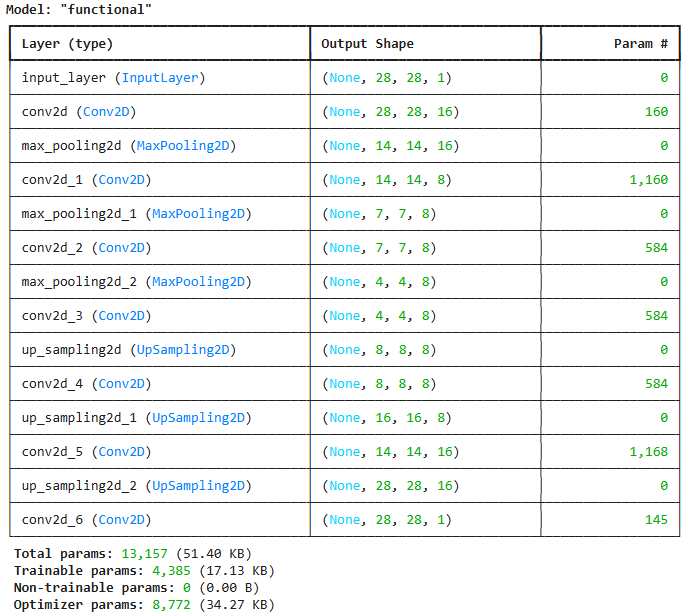



In [6]:
print("최대영", "2353881")

최대영 2353881


In [7]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

tigers7101@gmail.com


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from matplotlib import pyplot as plt

In [9]:
# gpu 확인
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## **데이터 불러오기**

In [10]:
from keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

## **모델 구조 생성**

In [11]:
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

# 코드를 작성해 주세요
# conv2d: (3,3) 커널, 16 필터 -> Params: (3*3*1 + 1)*16 = 160
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

# conv2d_1: (3,3) 커널, 8 필터 -> Params: (3*3*16 + 1)*8 = 1,160
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

# conv2d_2: (3,3) 커널, 8 필터 -> Params: (3*3*8 + 1)*8 = 584
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

# conv2d_3: (3,3) 커널, 8 필터 -> Params: (3*3*8 + 1)*8 = 584

# 인코더의 마지막 레이어 이름이 encoded == baseline max_pooling2D
encoded = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)

# up_sampling2d: (4, 4, 8) -> (8, 8, 8)
x = tf.keras.layers.UpSampling2D((2, 2))(encoded)

# conv2d_4: (3,3) 커널, 8 필터 -> Params: (3*3*8 + 1)*8 = 584
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)

# up_sampling2d_1: (8, 8, 8) -> (16, 16, 8)
x = tf.keras.layers.UpSampling2D((2, 2))(x)

# conv2d_5: (3,3) 커널, 16 필터, padding='valid' 기법 적용!!
# (16, 16, 8) 입력에 padding='valid' 및 (3,3) 커널을 적용하면 (16-3+1) = 14 가 되어
# 베이스라인의 (14, 14, 16) 셰이프와 파라미터 수 (3*3*8 + 1)*16 = 1,168 장치와 정확히 일치하게 됩니다.
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='valid')(x)

# up_sampling2d_2: (14, 14, 16) -> (28, 28, 16)
x = tf.keras.layers.UpSampling2D((2, 2))(x)

# 디코더의 마지막 레이어 이름이 decoded == baselind conv2d_6
decoded = tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = tf.keras.models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [12]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## **모델 학습**

In [13]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 145ms/step - loss: 0.2174 - val_loss: 0.1461
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - loss: 0.1366 - val_loss: 0.1279
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 143ms/step - loss: 0.1248 - val_loss: 0.1199
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.1186 - val_loss: 0.1152
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.1147 - val_loss: 0.1120
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 147ms/step - loss: 0.1119 - val_loss: 0.1096
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - loss: 0.1098 - val_loss: 0.1075
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 144ms/step - loss: 0.1080 - val_loss: 0.1060
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - loss: 0.1064 - val_loss: 0.1045
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 142ms/step - loss: 0.1051 - val_loss: 0.1036


## **모델 예측 시각화**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


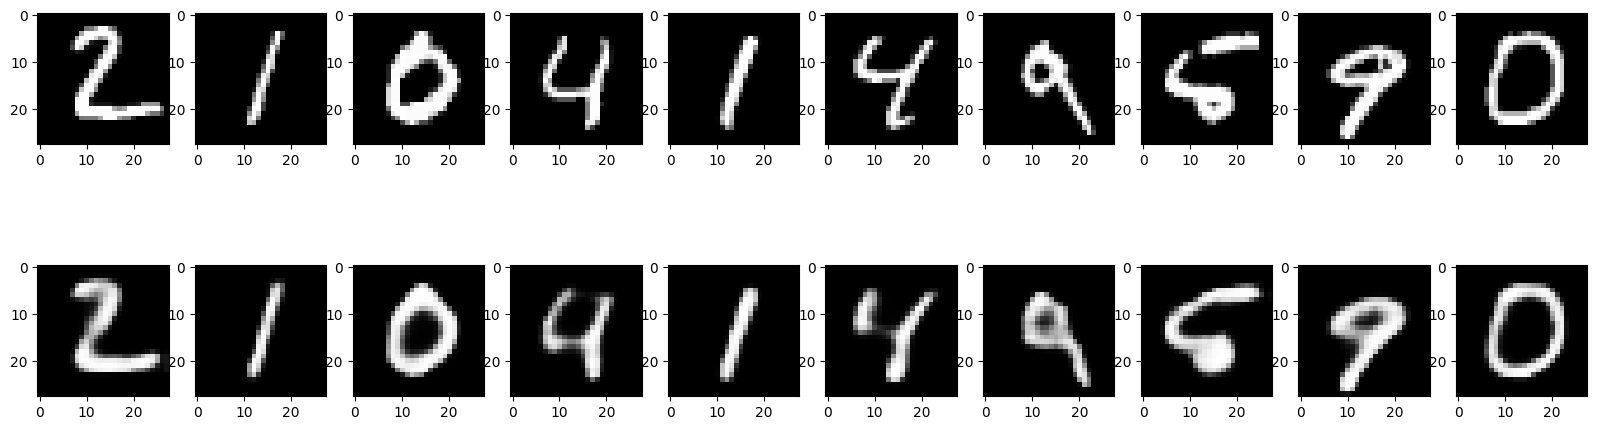

In [14]:
import matplotlib.pyplot as plt
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 6))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()

    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
plt.show()